# 4.5.2 非严格衰减与不能省略的条件

## 学习目标与先修知识

能用二维反例区分不增与吸引，分析零导数（derivative）集合中的运动，并为新区域写出可检查的充分不等式。

先修：上一节的正定（positive definite）、子水平集（sublevel set）和沿轨迹（trajectory）导数；二维旋转及范数（norm）。 [复习上一节](01-候选函数与局部稳定性证明.ipynb)。

## 具体问题

如果每次观察候选量都没有增加，为什么系统仍可能永远不恢复到平衡（equilibrium）？比较“持续转圈”和“只消除一个方向偏差”，再尝试加入非线性区域限制。

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from systems_science import plot_style, show_table
plot_style()
BLUE, PINK, GREEN, GRAY = '#008bfb', '#ff0051', '#009e73', '#555555'

## 初步实验

In [2]:
x,y=1.,2.
print('纯旋转的 V′ =',x*(-y)+y*x)
print('仅 x 衰减的 V′ =',x*(-x)+y*0)
print('二者都非正，却没有保证 y 回到 0。')

纯旋转的 V′ = 0.0
仅 x 衰减的 V′ = -1.0
二者都非正，却没有保证 y 回到 0。


## 模型假设

二维偏差 x、y 使用相同无量纲（dimensionless）尺度。比较系统一 (x′,y′)=(−y,x)，系统二 (−x,0)，以及阻尼旋转 (−αx−ωy,ωx−αy)。共同候选函数 V=(x²+y²)/2。

迁移模型（model）为 x′=−a x+(x²+y²)x，y′=−b y+(x²+y²)y，a,b>0；非线性项会在大幅度时抵消阻尼。只对开圆盘 ||(x,y)||<R 给出充分条件，不宣称找到了所有可用候选函数或最大吸引域（basin of attraction）。

## 数学解释与推导

纯旋转给出 V′=x(−y)+y*x=0，但 x²+y² 不为零的解一直沿圆走。原点稳定，因为小半径一直小；它不渐近稳定（asymptotic stability），因为半径不消失。

只衰减 x 的系统给 V′=−x²≤0，解为 x=x0 exp(−τ)、y=y0，最终停在 (0,y0)。零导数集合 x=0 里有整条非零平衡。由此可见，仅检查 V′≤0，不能跳过零导数集合上的运动。

在紧正向不变（positively invariant）集合等条件下，LaSalle 不变性原理（LaSalle invariance principle）可将渐近行为限制到 V′=0 集合中的最大不变子集。这里用它解释还要检查什么，完整证明留在拓展。本例的最大不变子集不只原点，故无法由此得到原点吸引所有邻近初值（initial condition）。

阻尼旋转则有 V′=−α(x²+y²)，旋转交叉项抵消。α>0 时严格负，α=0 回到纯旋转。函数正定与导数符号必须一起看。

对迁移模型，令 s=x²+y²，链式法则（chain rule）给出
$$V'= -a x^2-b y^2+s^2\le-\min(a,b)s+s^2=s(s-\min(a,b)).$$
因此当开圆盘半径满足 R²≤min(a,b) 时，盘内每个非零点都有 V′<0。等号仍可，因为讨论的是开圆盘 s<R²；边界不属于严格结论。再取 0<c<R²/2 的紧子水平集，得到局部稳定性证书。

这个条件是充分证书，不把“不满足证书”直接翻译成“该点不稳定”。有限点检验也不能代替这条对整个圆盘的解析上界。

## 核心实现

将推导中的每一步明确写成计算。

In [3]:
def quadratic_energy(points,alpha,omega):
    values=[];derivatives=[]
    for x,y in points:
        values.append((x*x+y*y)/2)
        rate=[-alpha*x-omega*y,omega*x-alpha*y]
        derivatives.append(x*rate[0]+y*rate[1])
    return values,derivatives

def regional_energy(points,a,b,radius):
    values=[];derivatives=[];strict=[]
    for x,y in points:
        square=x*x+y*y
        values.append(square/2)
        derivative=-a*x*x-b*y*y+square*square
        derivatives.append(derivative)
        strict.append(0<square<radius*radius and derivative<0)
    # A sufficient certificate on the full open disk, using the weakest damping.
    certificate=radius*radius<=min(a,b)
    return values,derivatives,strict,certificate

## 对照实验

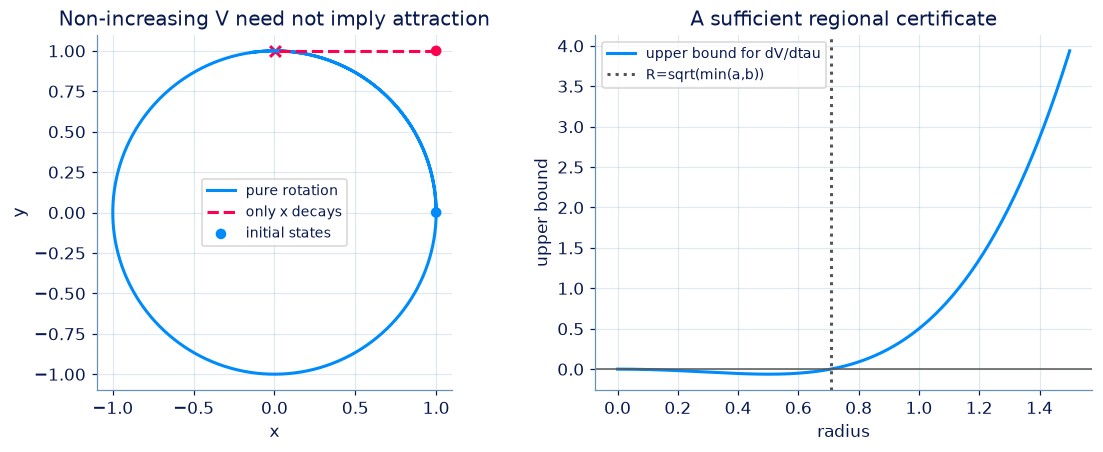

In [4]:
times=np.linspace(0,8,401)
rotation=np.column_stack([np.cos(times),np.sin(times)])
partial=np.column_stack([np.exp(-times),np.ones_like(times)])
fig,axes=plt.subplots(1,2,figsize=(10,4))
axes[0].plot(rotation[:,0],rotation[:,1],color=BLUE,label='pure rotation')
axes[0].plot(partial[:,0],partial[:,1],color=PINK,ls='--',label='only x decays')
axes[0].scatter([1,1],[0,1],color=[BLUE,PINK],s=35,label='initial states')
axes[0].scatter([partial[-1,0]],[partial[-1,1]],color=PINK,marker='x',s=50)
axes[0].set(xlabel='x',ylabel='y',aspect='equal',title='Non-increasing V need not imply attraction')
radius=np.linspace(0,1.5,301);minimum=.5
axes[1].plot(radius,radius**2*(radius**2-minimum),color=BLUE,label='upper bound for dV/dtau')
axes[1].axvline(np.sqrt(minimum),color=GRAY,ls=':',label='R=sqrt(min(a,b))')
axes[1].axhline(0,color=GRAY,lw=1)
axes[1].set(xlabel='radius',ylabel='upper bound',title='A sufficient regional certificate')
for ax in axes:ax.legend(fontsize=9)
plt.show()

## 结果解释

左图两种运动的 V 都不增加，但只有 x 衰减的轨迹会停下来，而且通常停在非零位置；纯旋转持续运动。圆点表示起点，叉号表示部分衰减的观察末态。右图展示区域上界，不是某条特定轨迹。

若要分析更大的区域，可以尝试其他候选函数，或进一步研究零导数集合上的运动。

### 独立核对

使用展开后的平方和表达式核对交叉项；单独检查开区域边界，避免把严格衰减和非严格边界混淆。

In [5]:
points=[[1,2],[-.5,.2],[0,0]]
for alpha in [0,.3]:
    values,derivatives=quadratic_energy(points,alpha,2)
    assert np.allclose(derivatives,[-alpha*(x*x+y*y) for x,y in points])
V,dV,inside,certificate=regional_energy([[0,0],[.5,0],[1,0]],1,2,1)
assert certificate and inside==[False,True,False]
assert dV==[0,-.1875,0]
assert not regional_energy([[.1,0]],.2,1,1)[-1]
print('交叉项抵消、开圆盘边界及充分条件接口通过。')

交叉项抵消、开圆盘边界及充分条件接口通过。


## 练习与参考资料

先独立作答，再提交核对。

### 第 1 题 · Python 计算题：旋转项是否改变总平方长度

二维系统 x′=−αx−ωy，y′=ωx−αy。计算 V=(x²+y²)/2 及沿轨迹（trajectory）导数（derivative）。

**函数与代码模板**

```python
def solve(
    points: list[list[float]],
    alpha: float,
    omega: float,
) -> tuple[list[float], list[float]]:
    # 根据已知条件计算，并按约定顺序返回。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `points` | `list[list[float]]` | 按 [x,y] 排列的状态（state）点。 | 1 |
| `alpha` | `float` | 非负阻尼系数。 | 1 |
| `omega` | `float` | 旋转角速度。 | 1 |

**返回值**

按以下顺序返回元组：(values, derivatives)。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `values` | `list[float]` | 各点候选函数 V。 | 1 |
| `derivatives` | `list[float]` | 各点 V′。 | 1 |

**计算规则**

先计算两个状态变化率，再使用 V′=x*x′+y*y′；代数核对为 −alpha*(x²+y²)，旋转交叉项抵消。

**约束与边界**

- 所有输入（input）数值有限；不修改输入列表。
- points 长度 1—30，每点两个分量，绝对值≤5；0≤alpha≤1；0≤omega≤3。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| points | 按 [x,y] 排列的状态（state）点。 | [[1, 0], [0, 2], [0, 0]] | 1 |
| alpha | 非负阻尼系数。 | 0.5 | 1 |
| omega | 旋转角速度。 | 2 | 1 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
points = [[1, 0], [0, 2], [0, 0]]
alpha = 0.5
omega = 2

result = solve(points, alpha, omega)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| values | 各点候选函数 V。 | [0.5, 2.0, 0.0] | 1 |
| derivatives | 各点 V′。 | [-0.5, -2.0, 0.0] | 1 |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = ([0.5, 2.0, 0.0], [-0.5, -2.0, 0.0])
```

**样例解释**

α=0.5 时三个 V 为 [0.5,2,0]，导数为 [−0.5,−2,0]；ω 不出现在最终导数中。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：旋转项是否改变总平方长度](http://127.0.0.1:8000/chapters/04-05-%E7%94%A8%20Lyapunov%20%E5%87%BD%E6%95%B0%E5%88%86%E6%9E%90%E7%A8%B3%E5%AE%9A%E6%80%A7/practice/?question=p04-rotating-energy)

### 第 2 题 · 单项选择题：导数非正能保证收敛到原点吗

纯旋转 x′=−y，y′=x，V=(x²+y²)/2。正确结论是？

- **A.** V′=0，原点稳定但不渐近稳定（asymptotic stability），非零轨迹（trajectory）沿圆旋转。
- **B.** V′=0，所有轨迹都保持同一个点。
- **C.** V>0，所以原点不稳定。
- **D.** V′≤0 足以保证所有轨迹到原点。

[作答：导数非正能保证收敛到原点吗](http://127.0.0.1:8000/chapters/04-05-%E7%94%A8%20Lyapunov%20%E5%87%BD%E6%95%B0%E5%88%86%E6%9E%90%E7%A8%B3%E5%AE%9A%E6%80%A7/practice/?question=p04-semidefinite-counterexample)

### 第 3 题 · 多项选择题：只对部分方向衰减会怎样

系统 x′=−x，y′=0，V=(x²+y²)/2。哪些成立？

- **A.** 所有初值（initial condition）都趋向原点。
- **B.** 初值 [1,2] 趋向 [0,2]。
- **C.** V′=0 的集合含非零平衡（equilibrium），不能由此宣布原点渐近稳定（asymptotic stability）。
- **D.** V′=−x²≤0。

[作答：只对部分方向衰减会怎样](http://127.0.0.1:8000/chapters/04-05-%E7%94%A8%20Lyapunov%20%E5%87%BD%E6%95%B0%E5%88%86%E6%9E%90%E7%A8%B3%E5%AE%9A%E6%80%A7/practice/?question=p04-missed-invariant-set)

### 第 4 题 · 单项选择题：有限采样可替代符号条件吗

在圆盘内抽取 1000 个点都得到 V′<0。哪项正确？

- **A.** 点数超过 100 就自动成为数学证明。
- **B.** 只检查边界更能保证所有内部点。
- **C.** 已严格证明每一点都小于零，包括原点。
- **D.** 这是数值支持；要宣称区域判据，还需解析不等式或有保证的全域核验。

[作答：有限采样可替代符号条件吗](http://127.0.0.1:8000/chapters/04-05-%E7%94%A8%20Lyapunov%20%E5%87%BD%E6%95%B0%E5%88%86%E6%9E%90%E7%A8%B3%E5%AE%9A%E6%80%A7/practice/?question=p04-sampled-proof)